In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [ ]:
#Define Paths
base_path = r"C:\Users\DELL\pythonprojects\emotion-recogntion-project\data\YOLO_format"

train_images = os.path.join(base_path, "train", "images")
valid_images = os.path.join(base_path, "valid", "images")
test_images  = os.path.join(base_path, "test", "images")

train_labels = os.path.join(base_path, "train", "labels")
valid_labels = os.path.join(base_path, "valid", "labels")
test_labels  = os.path.join(base_path, "test", "labels")

class_names = ["Anger", "Contempt", "Disgust", "Fear", 
               "Happy", "Neutral", "Sad", "Surprise"]

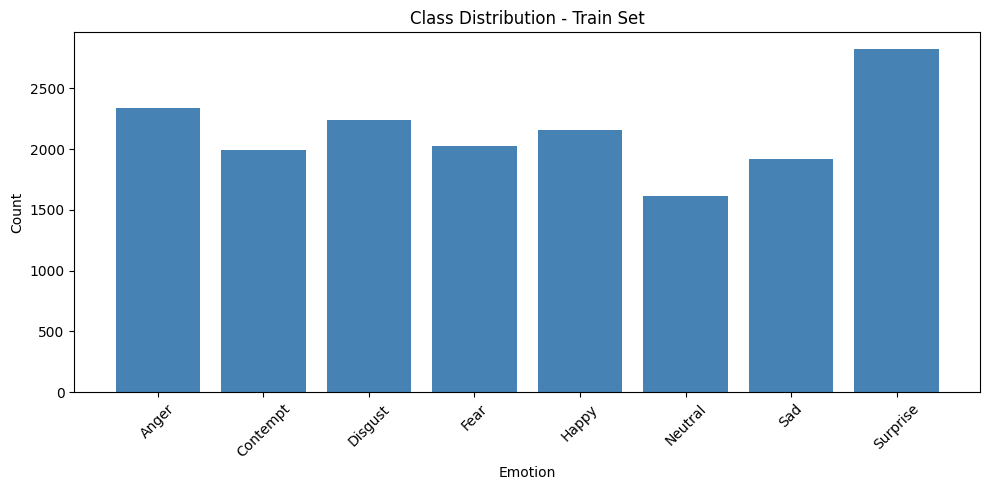

In [ ]:
#Check Class Distribution
def get_class_counts(labels_path):
    counts = Counter()
    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            with open(os.path.join(labels_path, file)) as f:
                for line in f:
                    class_id = int(line.split()[0])
                    counts[class_id] += 1
    return counts

train_counts = get_class_counts(train_labels)

# Plot
plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in sorted(train_counts)],
        [train_counts[i] for i in sorted(train_counts)],
        color="steelblue")
plt.title("Class Distribution - Train Set")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

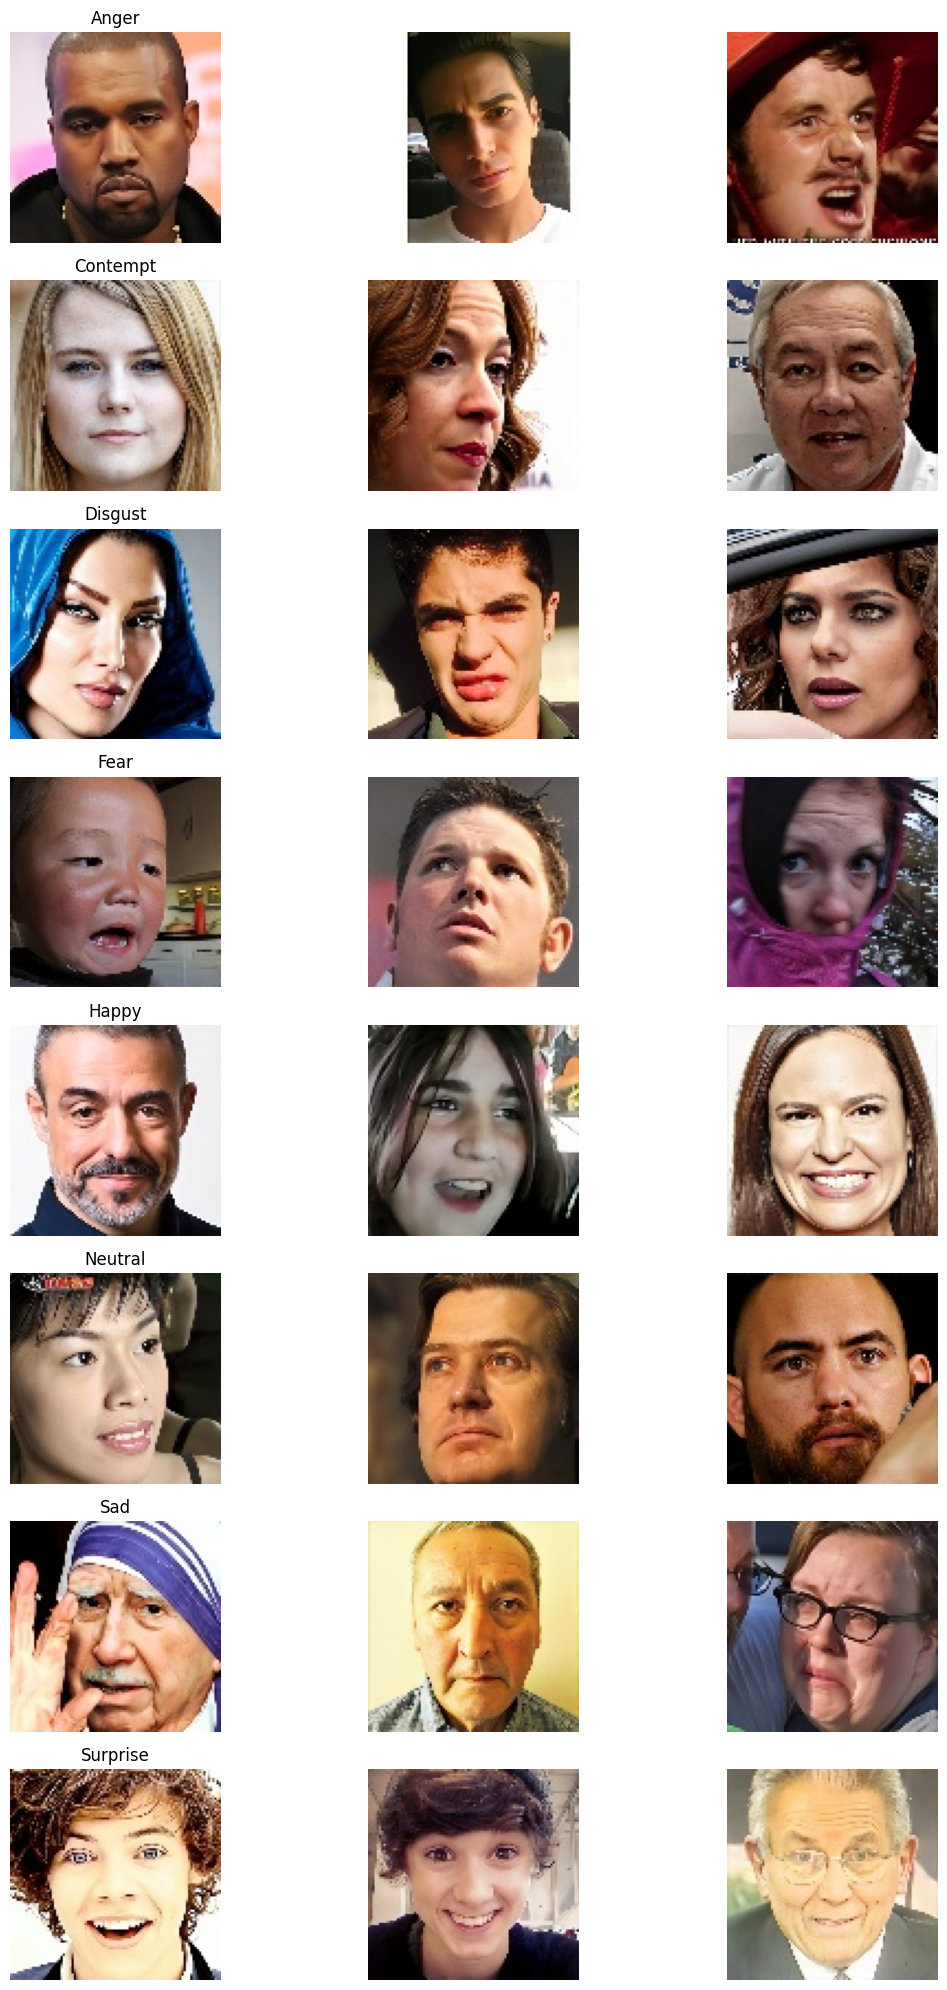

In [5]:
#Visualize Sample Images
def show_samples(images_path, labels_path, class_names, n=3):
    class_samples = {i: [] for i in range(len(class_names))}
    
    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            with open(os.path.join(labels_path, file)) as f:
                line = f.readline()
                if line:
                    class_id = int(line.split()[0])
                    img_file = file.replace(".txt", ".jpg")
                    img_path = os.path.join(images_path, img_file)
                    if os.path.exists(img_path):
                        class_samples[class_id].append(img_path)

    fig, axes = plt.subplots(len(class_names), n, figsize=(12, 20))
    for i, emotion in enumerate(class_names):
        samples = class_samples[i][:n]
        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axes[i][j].imshow(img)
            axes[i][j].axis("off")
            if j == 0:
                axes[i][j].set_title(emotion, fontsize=12)
    plt.tight_layout()
    plt.show()

show_samples(train_images, train_labels, class_names)

In [6]:
sizes = []
for file in os.listdir(train_images):
    if file.endswith(".jpg") or file.endswith(".png"):
        img = Image.open(os.path.join(train_images, file))
        sizes.append(img.size)

unique_sizes = Counter(sizes)
print("Unique image sizes found:")
for size, count in unique_sizes.most_common(10):
    print(f"  {size} → {count} images")

Unique image sizes found:
  (96, 96) → 17101 images


In [1]:
path= r"C:\Users\DELL\pythonprojects\emotion-recogntion-project\data\YOLO_format"
import os
train_data =[]
test_data =[]
valid_data =[]
splits = os.listdir(path)
print(splits)
for split in ["train" , "valid" , "test"]:
    images= os.listdir(f"{path}/{split}/images")
    for img in images :
        label_path = f"{path}/{split}/labels/{img[:-3]}txt"
        with open(label_path, "r") as f:
            line = f.readline()
            if line:
                class_id = int(line.split()[0])

        if split == "train":
            train_data.append({"image_path": f"{path}/{split}/images/{img}","class": class_id})
        elif split == "test":
            test_data.append({"image_path": f"{path}/{split}/images/{img}","class": class_id})
        elif split == "valid":
            valid_data.append({"image_path": f"{path}/{split}/images/{img}","class": class_id})

['data.yaml', 'test', 'train', 'valid']


In [2]:
len(train_data), len(valid_data), len(test_data)

(17101, 5406, 2755)